In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11665 entries, 0 to 11664
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    11665 non-null  int64  
 1   V1      11665 non-null  float64
 2   V2      11665 non-null  float64
 3   V3      11665 non-null  float64
 4   V4      11665 non-null  float64
 5   V5      11665 non-null  float64
 6   V6      11665 non-null  float64
 7   V7      11665 non-null  float64
 8   V8      11665 non-null  float64
 9   V9      11665 non-null  float64
 10  V10     11665 non-null  float64
 11  V11     11665 non-null  float64
 12  V12     11664 non-null  float64
 13  V13     11664 non-null  float64
 14  V14     11664 non-null  float64
 15  V15     11664 non-null  float64
 16  V16     11664 non-null  float64
 17  V17     11664 non-null  float64
 18  V18     11664 non-null  float64
 19  V19     11664 non-null  float64
 20  V20     11664 non-null  float64
 21  V21     11664 non-null  float64
 22

In [ ]:
genuine=len(df[df['Class']==0])
print(f'Genuine Transaction:{genuine}')
scam=len(df[df['Class']==1])
print(f'Scam or Fraud:{scam}')
per_of_fraud=(scam/(scam+genuine))*100
print('chance of fraud transaction:',per_of_fraud)

Genuine Transaction:11615
Scam or Fraud:49
chance of fraud transaction: 0.4200960219478738


In [ ]:
df['Amount'].describe()

,Amount
count,11664.000000
mean,62.795132
std,179.816783
min,0.000000
25%,5.000000
50%,15.950000
75%,50.000000
max,7712.430000


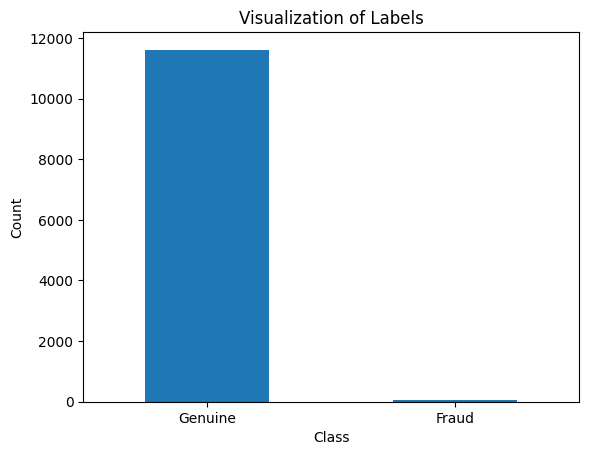

In [ ]:
import matplotlib.pyplot as plt
labels = ["Genuine", "Fraud"]
count_classes = df.value_counts(df['Class'], sort= True)
count_classes.plot(kind = "bar", rot = 0)
plt.title("Visualization of Labels")
plt.ylabel("Count")
plt.xticks(range(2), labels)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["NormalizedAmount"] = scaler.fit_transform(df["Amount"].values.reshape(-1, 1))
df.drop(["Amount", "Time"], inplace= True, axis= 1)

In [ ]:
df.dropna(inplace=True)
Y = df["Class"]
X = df.drop(["Class"], axis= 1)

In [ ]:
Y

,Class
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
11660,0.0
11661,0.0
11662,0.0
11663,0.0


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,train_size=.7,random_state=42)

In [ ]:
y_test

,Class
4012,0.0
1457,0.0
11431,0.0
6888,0.0
6333,0.0
...,...
4436,0.0
400,0.0
5277,0.0
4630,0.0


In [ ]:
print("Shape of train_X: ", x_test.shape)
print("Shape of test_X: ", x_train.shape)

Shape of train_X:  (3500, 29)
Shape of test_X:  (8165, 29)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
rf = RandomForestClassifier(n_estimators= 100)

In [ ]:
dt.fit(x_train,y_train)
ydt_pred=dt.predict(x_test)

In [ ]:
rf.fit(x_train,y_train)
yrf_pred=rf.predict(x_test)

In [ ]:
nan_indices = y_test.index[y_test.isna()]
x_test_cleaned = x_test.drop(nan_indices)
y_test_cleaned = y_test.drop(nan_indices)

decision_tree_score = dt.score(x_test_cleaned, y_test_cleaned) * 100
decision_tree_score

99.85710202915119

In [ ]:
nan_indices = y_test.index[y_test.isna()]
x_test_cleaned = x_test.drop(nan_indices)
y_test_cleaned = y_test.drop(nan_indices)

Randome_forest_score = rf.score(x_test_cleaned, y_test_cleaned) * 100
Randome_forest_score

99.9142612174907

In [ ]:
ydt_pred[:20]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score, f1_score

In [ ]:
def metrics(actuals, predictions):
    print("Accuracy: {:.5f}".format(accuracy_score(actuals, predictions)))
    print("Precision: {:.5f}".format(precision_score(actuals, predictions)))
    print("Recall: {:.5f}".format(recall_score(actuals, predictions)))
    print("F1-score: {:.5f}".format(f1_score(actuals, predictions)))

In [ ]:
nan_indices = y_test.index[y_test.isna()]
ydt_pred_cleaned = pd.Series(ydt_pred, index=x_test.index).drop(nan_indices)
confusion_matrix_dt = confusion_matrix(y_test_cleaned, ydt_pred_cleaned.round())
print("Confusion Matrix - Decision Tree")
print(confusion_matrix_dt)

Confusion Matrix - Decision Tree
[[3479    3]
 [   2   15]]


In [ ]:
metrics(y_test_cleaned, ydt_pred_cleaned)

Accuracy: 0.99857
Precision: 0.83333
Recall: 0.88235
F1-score: 0.85714
